# 03 — Эксперименты: Полиномиальные признаки и PCA

Анализируем логистическую регрессию в 3 вариантах:
1. **Baseline** (исходные признаки)
2. **Polynomial Features** (полиномы 2-й степени для поиска нелинейных связей)
3. **PCA** (снижение размерности для уменьшения шума и мультиколлинеарности с сохранением 95% дисперсии)

## 0. Настройка

In [1]:
import sys
sys.path.insert(0, "..")
import warnings
warnings.filterwarnings("ignore")
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, roc_auc_score, average_precision_score, precision_recall_curve
from src.preprocessing import load_processed, RAW_FEATURES
from src.modeling import train_logistic_baseline, train_polynomial_logistic, train_pca_logistic, save_model
plt.rcParams["figure.dpi"] = 120

## 1. Загрузка данных

In [2]:
splits = load_processed()
X_train, X_val, X_test = splits["X_train"], splits["X_val"], splits["X_test"]
y_train, y_val, y_test = splits["y_train"], splits["y_val"], splits["y_test"]

## 2. Обучение моделей

In [3]:
# Baseline: Логистическая регрессия
res_log = train_logistic_baseline(X_train, y_train.values, X_val, y_val.values, X_test, y_test.values)

# Полиномиальная регрессия
res_poly = train_polynomial_logistic(X_train, y_train.values, X_val, y_val.values, X_test, y_test.values, degree=2)

# RCA
res_pca = train_pca_logistic(X_train, y_train.values, X_val, y_val.values, X_test, y_test.values, n_components=0.95)

## 3. Сравнение классификаторов: ROC и PR-кривые

Анализируем графики, чтобы понять, какой подход работает лучше в условиях несбалансированных классов.

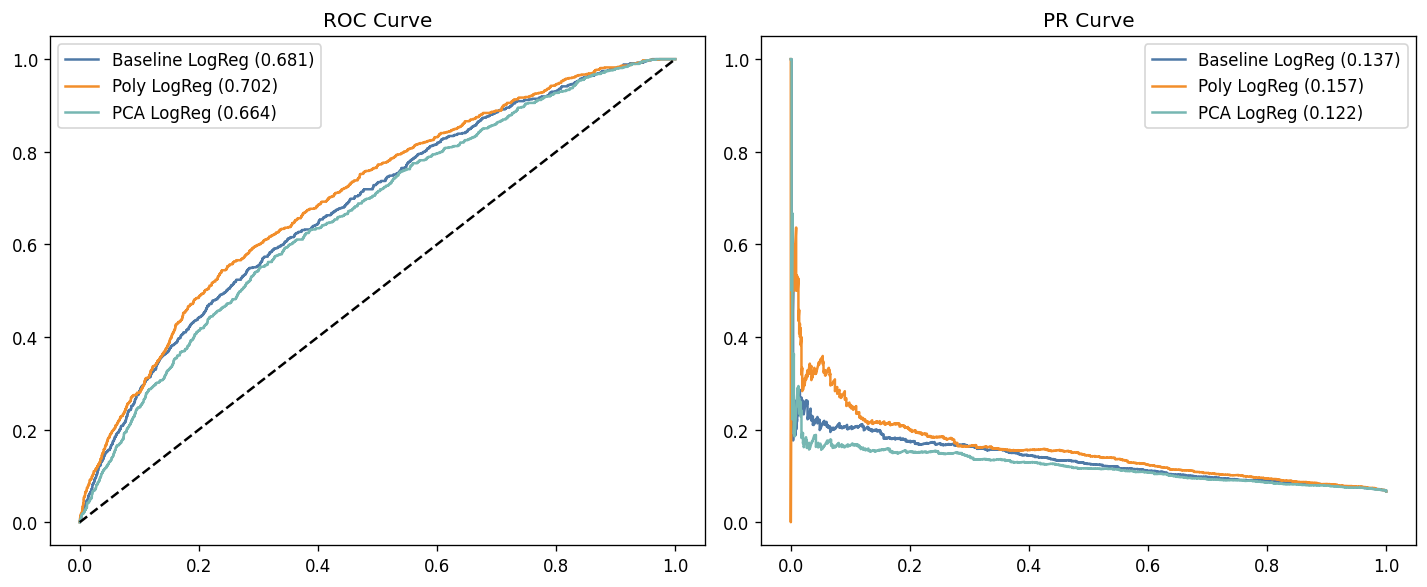

In [4]:
model_probs = [
    (res_log["model"].predict_proba(X_test)[:, 1], "Baseline LogReg", "#4e79a7"),
    (res_poly["model"].predict_proba(X_test)[:, 1], "Poly LogReg", "#f28e2b"),
    (res_pca["model"].predict_proba(X_test)[:, 1], "PCA LogReg", "#76b7b2"),
]

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# ROC
ax = axes[0]
for prob, label, color in model_probs:
    fpr, tpr, _ = roc_curve(y_test.values, prob)
    auc = roc_auc_score(y_test.values, prob)
    ax.plot(fpr, tpr, label=f"{label} ({auc:.3f})", color=color)
ax.plot([0, 1], [0, 1], "k--")
ax.set_title("ROC Curve"); ax.legend()

# PR
ax = axes[1]
for prob, label, color in model_probs:
    prec, rec, _ = precision_recall_curve(y_test.values, prob)
    ap = average_precision_score(y_test.values, prob)
    ax.plot(rec, prec, label=f"{label} ({ap:.3f})", color=color)
ax.set_title("PR Curve"); ax.legend()

plt.tight_layout()
plt.show()

## 4. Сохранение лучшей модели

In [5]:
save_model(res_poly["model"], "poly_logistic")

  Сохранено в D:\hseml-group-project-yuliasx\models\poly_logistic.pkl


WindowsPath('D:/hseml-group-project-yuliasx/models/poly_logistic.pkl')